# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Mahardika Indra Pratama Ilyasa | 5054251045 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [3]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


from kagglehub import KaggleDatasetAdapter
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Dataset berhasil diunduh dari: ", path)


files = os.listdir(path)
csv_filename = [f for f in files if f.endswith('.csv')][0]
csv_path = os.path.join(path, csv_filename)
df = pd.read_csv(csv_path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Dataset berhasil diunduh dari:  /kaggle/input/telco-customer-churn


In [4]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
csv_path = "churn.csv"
print("Ukuran dataset: ", df.shape)
print("=====5 data pertama=====")
print(df.head())
print("=====Info dataset=====")
print(df.info())
print("=====Statistik deskriptif=====")
print(df.describe())
print("=====Jumlah missing value=====")
print(df.isnull().sum())

Ukuran dataset:  (7043, 21)
=====5 data pertama=====
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSup

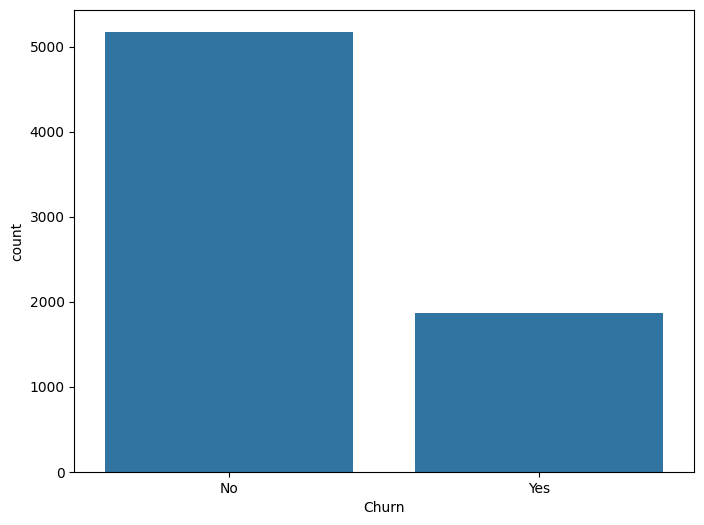

Persentase distribusi kelas target:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64
Berdasarkan hasil distribusi kelas ini dapat dilihat bahwa data imbalance


In [5]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
target_col = 'Churn'
plt.figure(figsize=(8, 6))
sns.countplot(x='Churn', data=df)
plt.show()
print("Persentase distribusi kelas target:")
print(df[target_col].value_counts(normalize=True) * 100)
print("Berdasarkan hasil distribusi kelas ini dapat dilihat bahwa data imbalance")

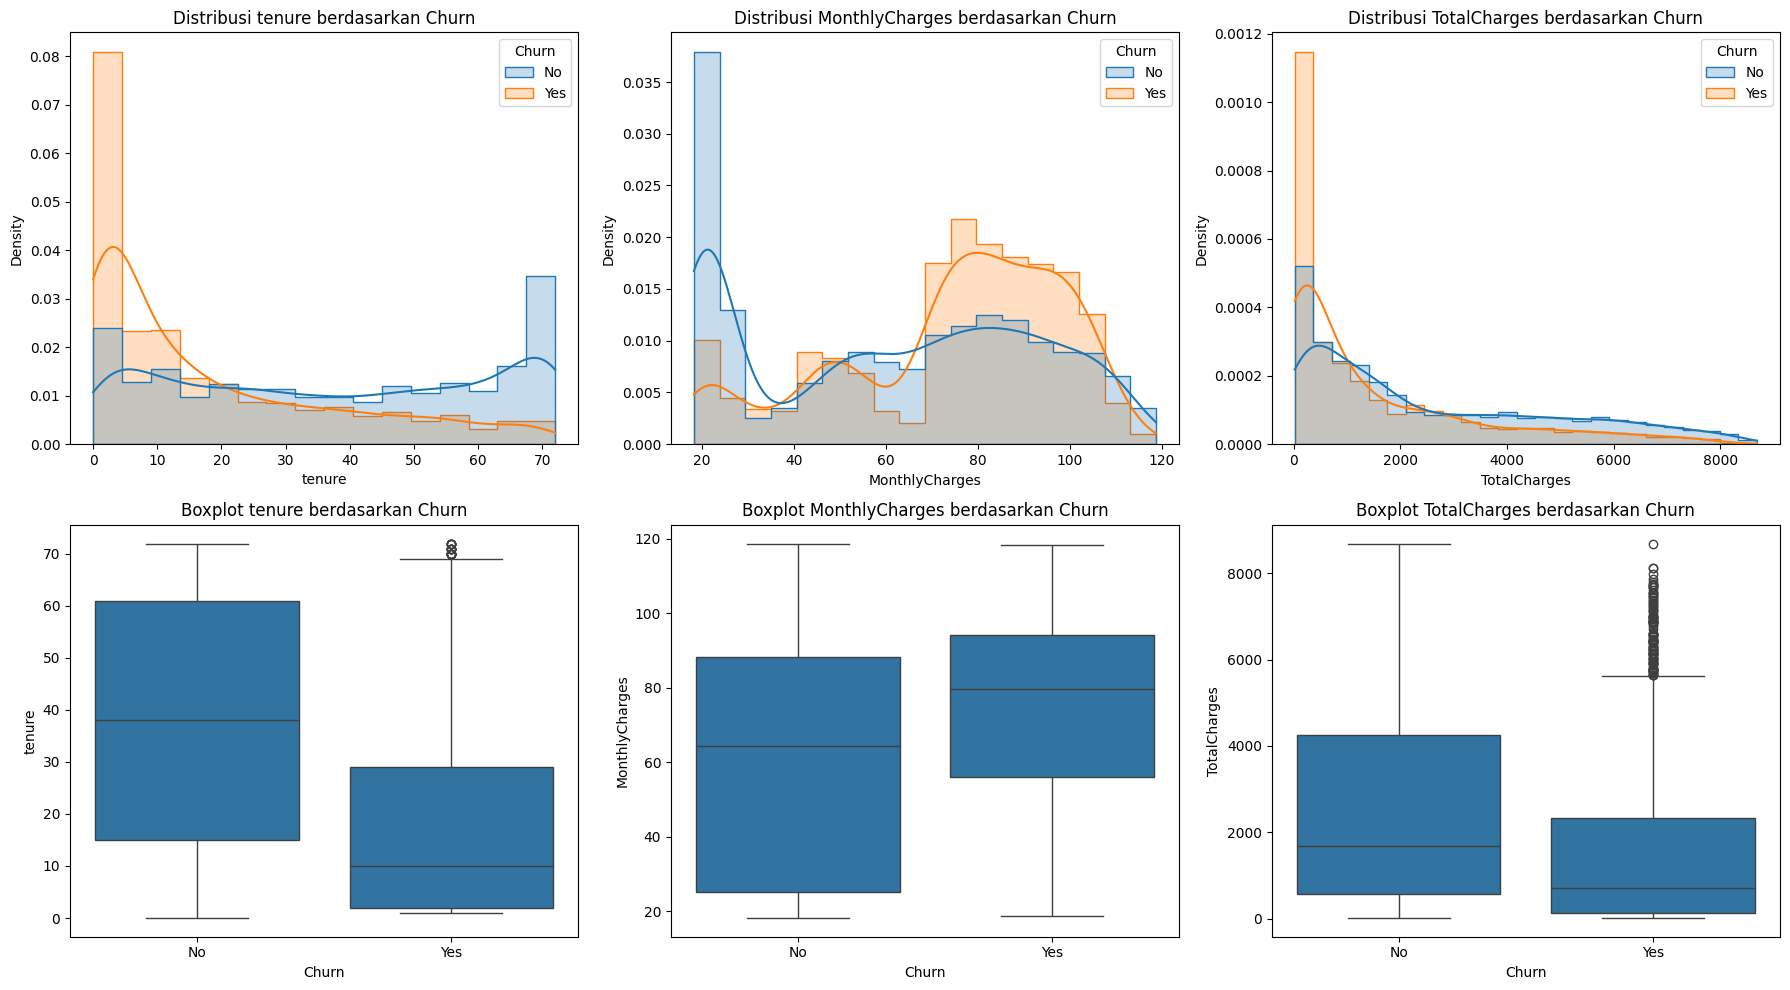

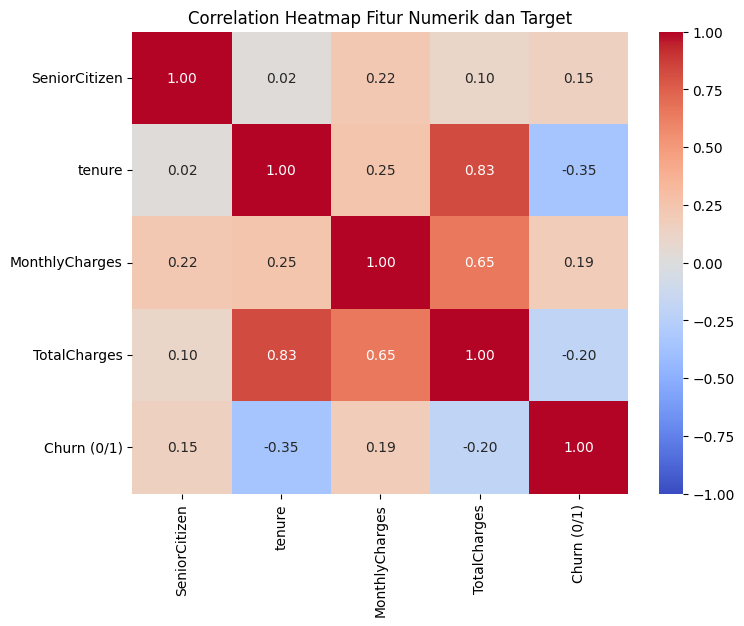

Setelah dicek lebih lanjut menggunakan histogram, boxplot, dan heatmap terlihat bahwa dataset memang tidak balance


In [6]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau correlation heatmap), dibedakan berdasarkan kelas target.
# TotalCharges terbaca sebagai object (ada nilai spasi), jadi dikonversi dulu ke numerik pada salinan df khusus EDA
df_eda = df.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Histogram (atas) dan boxplot (bawah) fitur numerik, dibedakan berdasarkan kelas target Churn
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(num_features):
    sns.histplot(data=df_eda, x=col, hue='Churn', kde=True, stat='density',
                 common_norm=False, element='step', ax=axes[0, i])
    axes[0, i].set_title(f'Distribusi {col} berdasarkan Churn')
    sns.boxplot(data=df_eda, x='Churn', y=col, ax=axes[1, i])
    axes[1, i].set_title(f'Boxplot {col} berdasarkan Churn')
plt.tight_layout()
plt.show()

# Correlation heatmap fitur numerik + target (Churn diubah ke 0/1 hanya untuk keperluan korelasi)
df_corr = df_eda[['SeniorCitizen'] + num_features].copy()
df_corr['Churn (0/1)'] = (df_eda['Churn'] == 'Yes').astype(int)
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap Fitur Numerik dan Target')
plt.show()
print("Setelah dicek lebih lanjut menggunakan histogram, boxplot, dan heatmap terlihat bahwa dataset memang tidak balance")

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

**EDA tambahan yang digunakan:**

| No | Teknik | Tujuan |
|----|--------|--------|
| 1 | Cek missing value tersembunyi + duplikasi | `isnull()` menunjukkan 0 missing, padahal `TotalCharges` bertipe `object` (ada nilai spasi). Dicek juga duplikasi baris/`customerID`. |
| 2 | Churn rate per kategori (bar plot) | Melihat kategori mana yang tingkat churn-nya jauh di atas/bawah rata-rata keseluruhan. |
| 3 | Uji Chi-Square + Cramér's V (kategorikal) dan Mann-Whitney U (numerik) | Mengukur secara statistik kekuatan hubungan tiap fitur dengan target, sehingga tidak hanya mengandalkan visual. |
| 4 | Churn rate per kelompok tenure/MonthlyCharges, deteksi outlier (IQR), dan korelasi antar fitur numerik | Melihat pola non-linear, outlier, dan potensi multikolinearitas. |

In [7]:
# Cek missing value tersembunyi dan duplikasi
blank_mask = df['TotalCharges'].astype(str).str.strip() == ''
print("Jumlah TotalCharges kosong (berisi spasi):", blank_mask.sum())
print(df.loc[blank_mask, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])
print("\nJumlah pelanggan dengan tenure == 0:", (df['tenure'] == 0).sum())
print("Jumlah customerID duplikat:", df['customerID'].duplicated().sum())
print("Jumlah baris duplikat:", df.duplicated().sum())

Jumlah TotalCharges kosong (berisi spasi): 11
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No

Jumlah pelanggan dengan tenure == 0: 11
Jumlah customerID duplikat: 0
Jumlah baris duplikat: 0


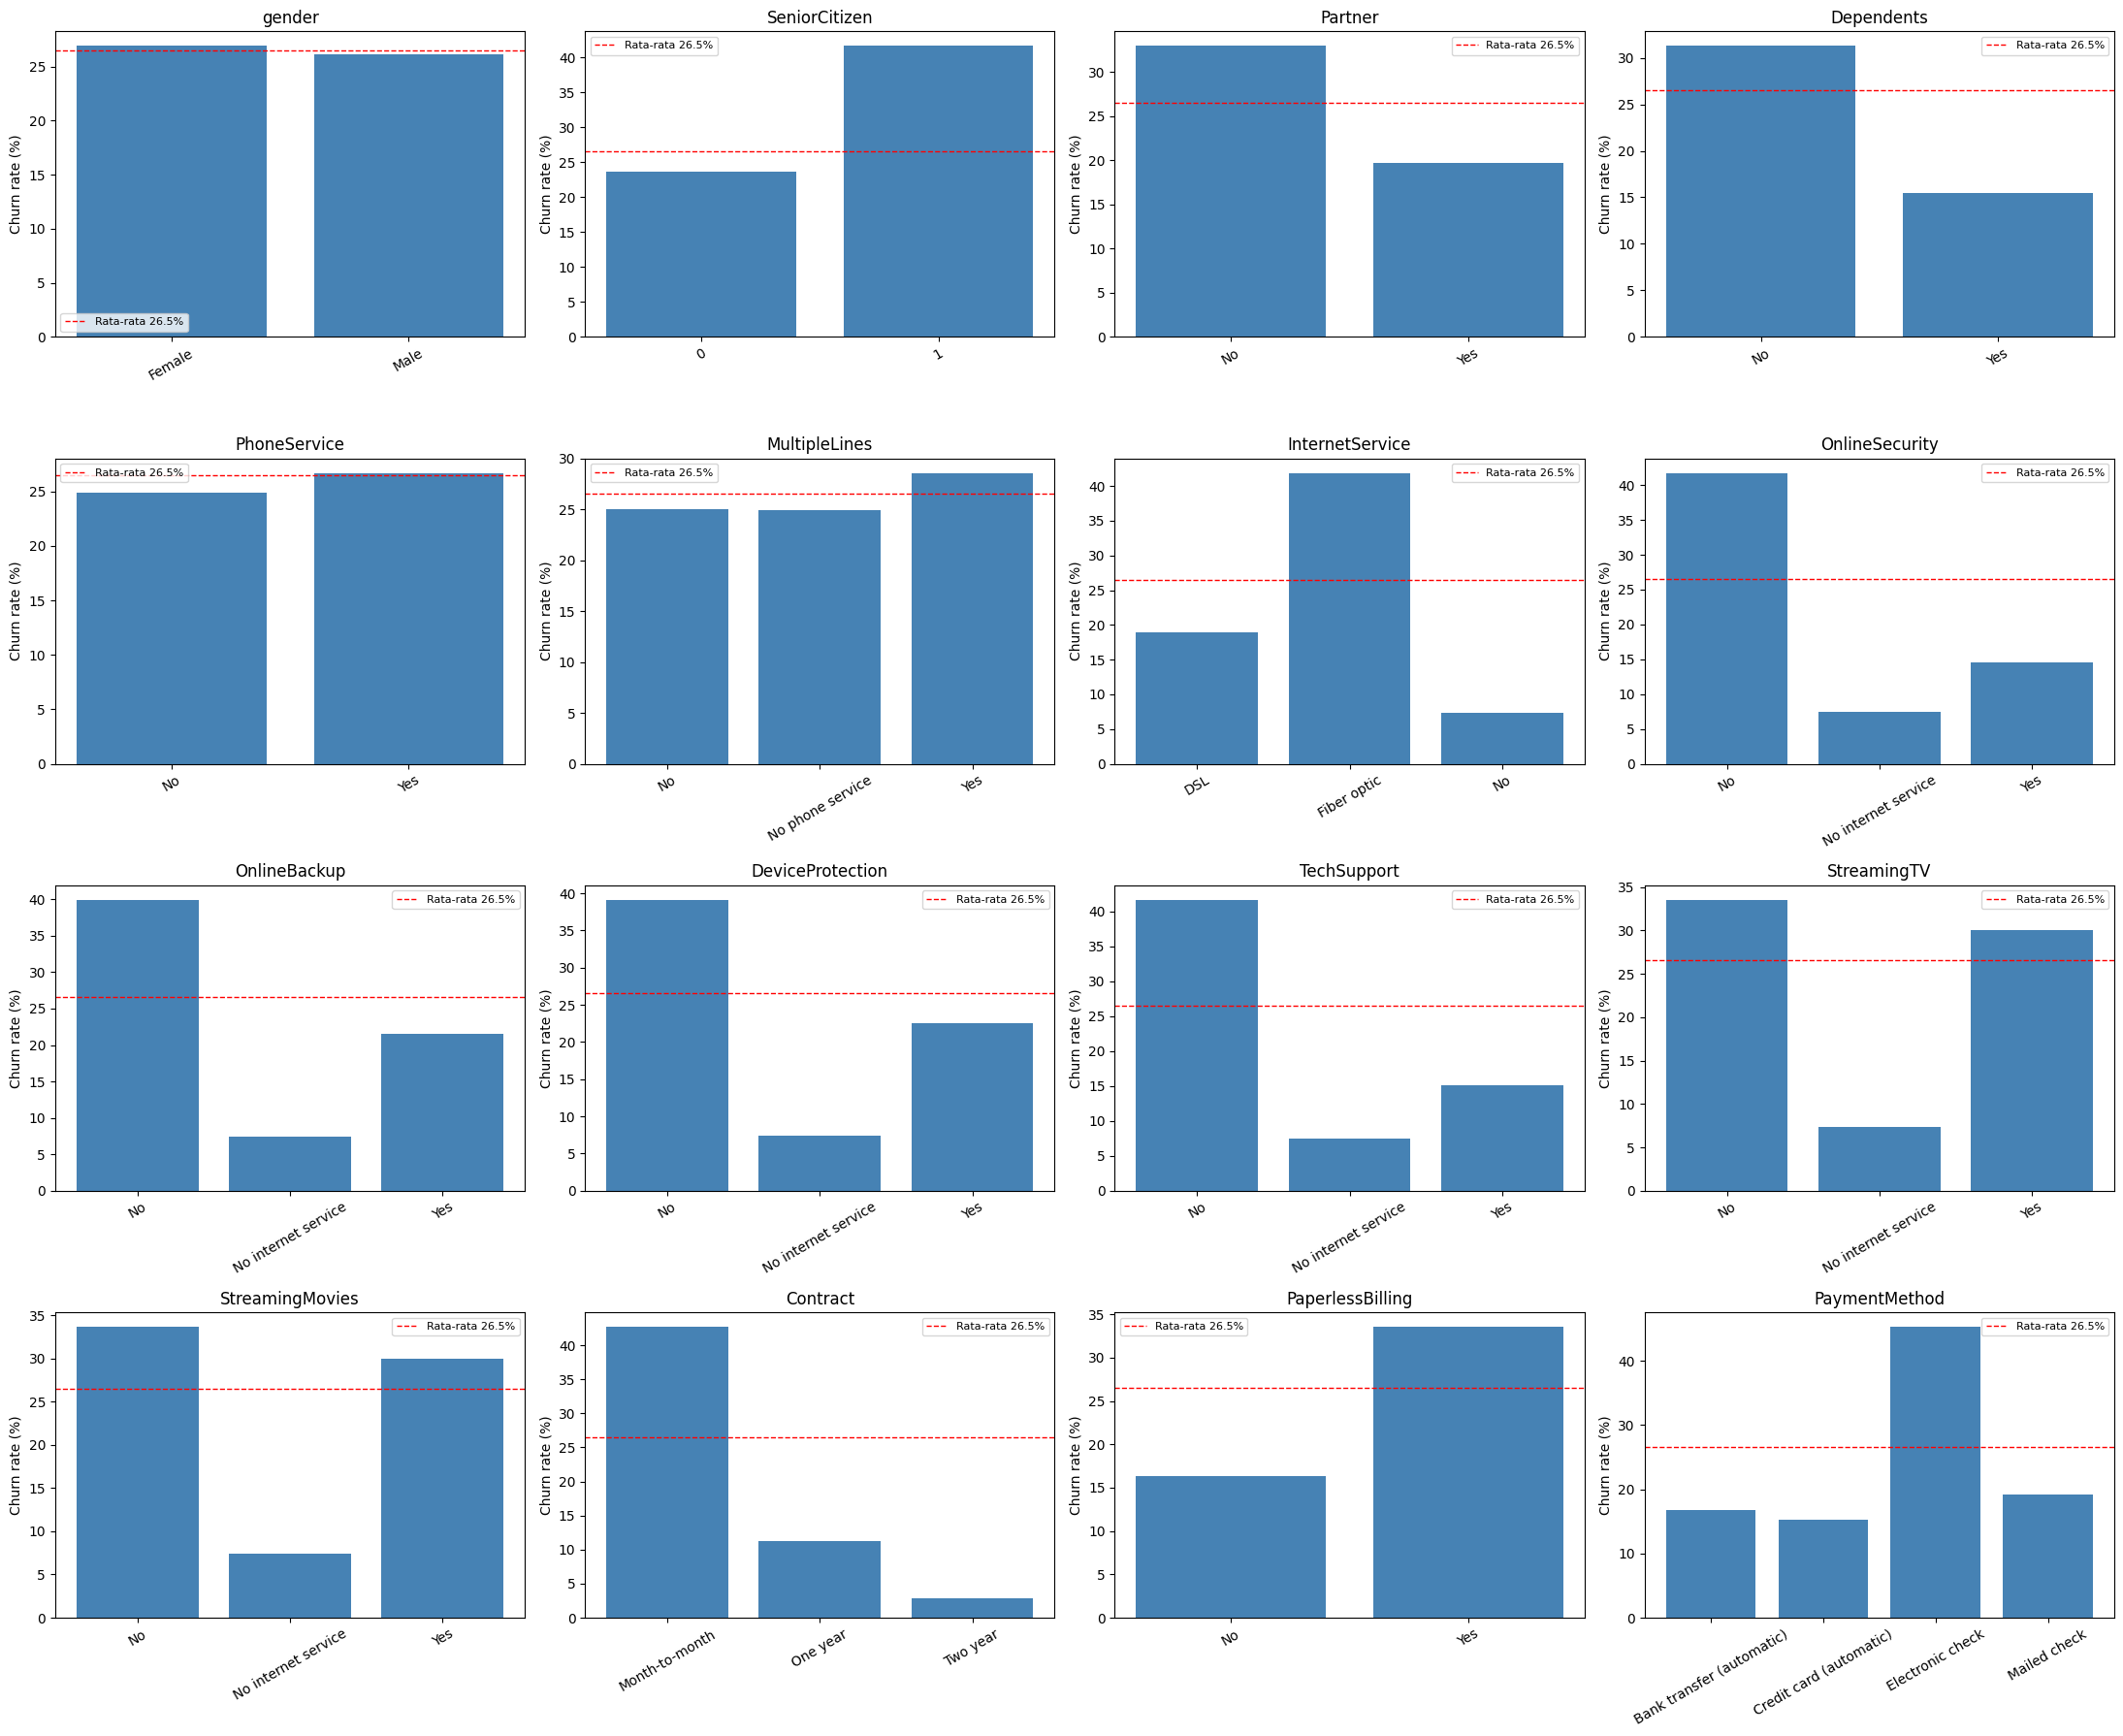

In [8]:
#Churn rate (%) per kategori pada setiap fitur kategorikal
cat_features = [c for c in df.select_dtypes(exclude='number').columns if c not in ['customerID', 'Churn', 'TotalCharges']]
cat_features.insert(1, 'SeniorCitizen')
churn_flag = (df['Churn'] == 'Yes').astype(int)
overall_rate = churn_flag.mean() * 100

fig, axes = plt.subplots(4, 4, figsize=(22, 18))
for ax, col in zip(axes.flatten(), cat_features):
    rate = churn_flag.groupby(df[col]).mean() * 100
    ax.bar(rate.index.astype(str), rate.values, color='steelblue')
    ax.axhline(overall_rate, color='red', linestyle='--', linewidth=1, label=f'Rata-rata {overall_rate:.1f}%')
    ax.set_title(col)
    ax.set_ylabel('Churn rate (%)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

               Fitur       Chi2  p-value  Cramer's V
0           Contract  1184.5966   0.0000      0.4101
1     OnlineSecurity   849.9990   0.0000      0.3474
2        TechSupport   828.1971   0.0000      0.3429
3    InternetService   732.3096   0.0000      0.3225
4      PaymentMethod   648.1423   0.0000      0.3034
5       OnlineBackup   601.8128   0.0000      0.2923
6   DeviceProtection   558.4194   0.0000      0.2816
7    StreamingMovies   375.6615   0.0000      0.2310
8        StreamingTV   374.2039   0.0000      0.2305
9   PaperlessBilling   259.1610   0.0000      0.1918
10        Dependents   189.9403   0.0000      0.1642
11     SeniorCitizen   160.3521   0.0000      0.1509
12           Partner   159.4145   0.0000      0.1504
13     MultipleLines    11.3304   0.0035      0.0401
14      PhoneService     1.0044   0.3162      0.0119
15            gender     0.5224   0.4698      0.0086


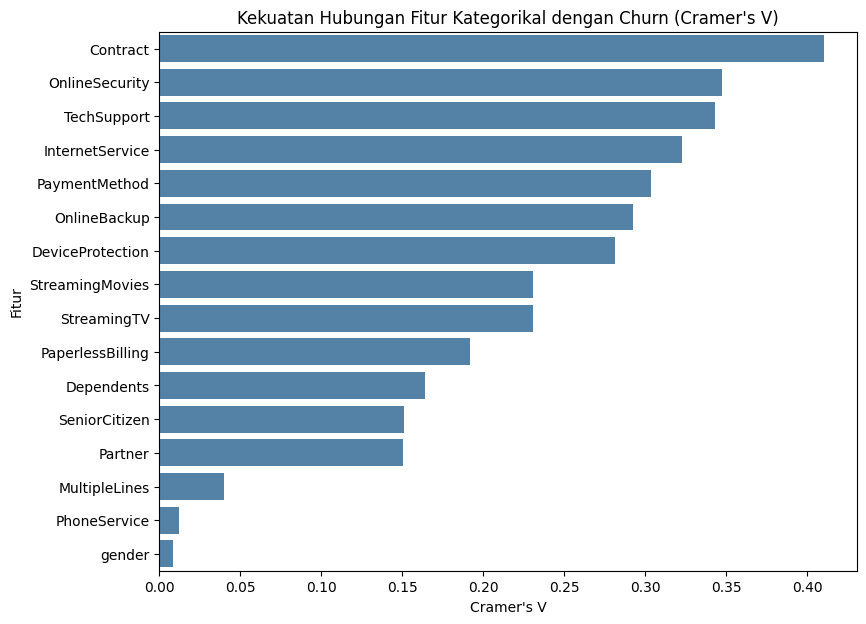


Uji Mann-Whitney U fitur numerik:
            Fitur  Median (No)  Median (Yes)  p-value
0          tenure       38.000         10.00      0.0
1  MonthlyCharges       64.425         79.65      0.0
2    TotalCharges     1683.600        703.55      0.0


In [9]:
# Uji statistik hubungan fitur dengan target
from scipy.stats import chi2_contingency, mannwhitneyu

# (a) Fitur kategorikal: Chi-Square test + Cramer's V (kekuatan hubungan, rentang 0-1)
rows = []
for col in cat_features:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, _ = chi2_contingency(ct, correction=False)
    n = ct.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    rows.append({'Fitur': col, 'Chi2': chi2, 'p-value': p, "Cramer's V": cramers_v})
cat_assoc = pd.DataFrame(rows).sort_values("Cramer's V", ascending=False).reset_index(drop=True)
print(cat_assoc.round(4))

plt.figure(figsize=(9, 7))
sns.barplot(data=cat_assoc, y='Fitur', x="Cramer's V", color='steelblue')
plt.title("Kekuatan Hubungan Fitur Kategorikal dengan Churn (Cramer's V)")
plt.show()

# (b) Fitur numerik: Mann-Whitney U test (tanpa asumsi distribusi normal) antara kelompok Churn vs Tidak Churn
rows = []
for col in num_features:
    g_no = df_eda.loc[df_eda['Churn'] == 'No', col].dropna()
    g_yes = df_eda.loc[df_eda['Churn'] == 'Yes', col].dropna()
    stat, p = mannwhitneyu(g_no, g_yes, alternative='two-sided')
    rows.append({'Fitur': col, 'Median (No)': g_no.median(), 'Median (Yes)': g_yes.median(), 'p-value': p})
print("\nUji Mann-Whitney U fitur numerik:")
print(pd.DataFrame(rows).round(4))

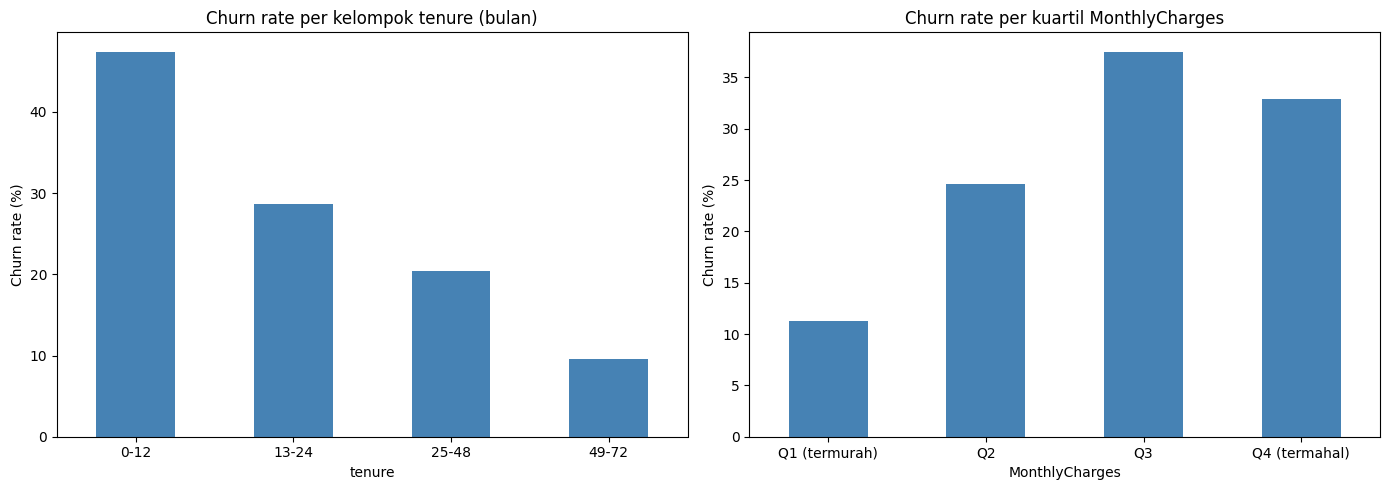

Jumlah outlier (aturan IQR):
  tenure: 0
  MonthlyCharges: 0
  TotalCharges: 0

Korelasi antar fitur numerik:
                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000


In [10]:
# Pola non-linear (binning), outlier (IQR), dan korelasi antar fitur numerik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tenure_bin = pd.cut(df_eda['tenure'], bins=[-1, 12, 24, 48, 72], labels=['0-12', '13-24', '25-48', '49-72'])
(churn_flag.groupby(tenure_bin, observed=True).mean() * 100).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Churn rate per kelompok tenure (bulan)')
axes[0].set_ylabel('Churn rate (%)')
axes[0].tick_params(axis='x', rotation=0)

charge_bin = pd.qcut(df_eda['MonthlyCharges'], q=4, labels=['Q1 (termurah)', 'Q2', 'Q3', 'Q4 (termahal)'])
(churn_flag.groupby(charge_bin, observed=True).mean() * 100).plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Churn rate per kuartil MonthlyCharges')
axes[1].set_ylabel('Churn rate (%)')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# Deteksi outlier dengan aturan IQR
print("Jumlah outlier (aturan IQR):")
for col in num_features:
    q1, q3 = df_eda[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df_eda[col] < q1 - 1.5 * iqr) | (df_eda[col] > q3 + 1.5 * iqr)).sum()
    print(f"  {col}: {n_out}")

# Korelasi antar fitur numerik untuk melihat potensi multikolinearitas
print("\nKorelasi antar fitur numerik:")
print(df_eda[num_features].corr().round(3))

# 2. Preprocessing

In [11]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
df_clean = df.copy()

# Ubah ke numerik nilai spasi menjadi NaN.
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
print("Missing value TotalCharges setelah konversi:", df_clean['TotalCharges'].isnull().sum())

mask_new_customer = df_clean['TotalCharges'].isnull() & (df_clean['tenure'] == 0)
df_clean.loc[mask_new_customer, 'TotalCharges'] = 0
print("Missing value TotalCharges setelah imputasi:", df_clean['TotalCharges'].isnull().sum())

Missing value TotalCharges setelah konversi: 11
Missing value TotalCharges setelah imputasi: 0


In [12]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# customerID hanya identitas unik (bukan fitur prediktif) sehingga dibuang
df_clean = df_clean.drop(columns=['customerID'])

df_clean['Churn'] = df_clean['Churn'].map({'No': 0, 'Yes': 1})

cat_cols = df_clean.select_dtypes(exclude='number').columns.tolist()
print("Fitur kategorikal yang di-encode:", cat_cols)
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True, dtype=int)
print("Ukuran data setelah encoding:", df_encoded.shape)

Fitur kategorikal yang di-encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Ukuran data setelah encoding: (7043, 31)


In [13]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Ukuran X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Proporsi Churn y_train:", round(y_train.mean() * 100, 2), "% | y_test:", round(y_test.mean() * 100, 2), "%")

Ukuran X_train: (5634, 30) | X_test: (1409, 30)
Proporsi Churn y_train: 26.54 % | y_test: 26.54 %


In [14]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']   # fitur biner hasil one-hot (0/1) tidak perlu discaling

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("Mean fitur numerik train setelah scaling (harusnya ~0):")
print(X_train_scaled[num_cols].mean().round(4))

Mean fitur numerik train setelah scaling (harusnya ~0):
tenure           -0.0
MonthlyCharges   -0.0
TotalCharges      0.0
dtype: float64


# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [15]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer (misalnya hidden_layer_sizes=(10,))
# dan activation='relu' menggunakan train set (yang sudah discaling).
mlp_base = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', max_iter=500, random_state=42)
mlp_base.fit(X_train_scaled, y_train)
print("Model baseline selesai dilatih. Jumlah iterasi:", mlp_base.n_iter_)

Model baseline selesai dilatih. Jumlah iterasi: 326


In [16]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_base = mlp_base.predict(X_test_scaled)
print("Akurasi test baseline (ReLU, (10,)):", round(accuracy_score(y_test, y_pred_base), 4))

Akurasi test baseline (ReLU, (10,)): 0.797


## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [17]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama (hidden_layer_sizes, max_iter, random_state) agar perbandingan adil.
activations = ['relu', 'tanh', 'logistic']
models_act = {}
for act in activations:
    model = MLPClassifier(hidden_layer_sizes=(10,), activation=act, max_iter=500, random_state=42)
    model.fit(X_train_scaled, y_train)
    models_act[act] = model
    print(f"Model activation='{act}' selesai dilatih (iterasi: {model.n_iter_})")

Model activation='relu' selesai dilatih (iterasi: 326)


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Model activation='tanh' selesai dilatih (iterasi: 500)
Model activation='logistic' selesai dilatih (iterasi: 153)


In [18]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan.
results_act = []
for act, model in models_act.items():
    results_act.append({
        'Activation': act,
        'Train Accuracy': accuracy_score(y_train, model.predict(X_train_scaled)),
        'Test Accuracy': accuracy_score(y_test, model.predict(X_test_scaled)),
        'Jumlah Iterasi': model.n_iter_
    })
results_act_df = pd.DataFrame(results_act).set_index('Activation')
print(results_act_df.round(4))

best_act = results_act_df['Test Accuracy'].idxmax()
print("\nActivation terbaik berdasarkan akurasi test:", best_act)

            Train Accuracy  Test Accuracy  Jumlah Iterasi
Activation                                               
relu                0.8170         0.7970             326
tanh                0.8225         0.7864             500
logistic            0.8062         0.8013             153

Activation terbaik berdasarkan akurasi test: logistic


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [19]:
# Latih beberapa model MLPClassifier dengan variasi hidden_layer_sizes,
# misalnya (2,), (5,), (10,), (50,), (100, 50).
# Gunakan activation terbaik dari hasil eksperimen 3.2, dan hyperparameter lain yang sama.
architectures = {
    '(2,)': (2,),
    '(5,)': (5,),
    '(10,)': (10,),
    '(50,)': (50,),
    '(100, 50)': (100, 50)
}
models_arch = {}
for name, hls in architectures.items():
    model = MLPClassifier(hidden_layer_sizes=hls, activation=best_act, max_iter=500, random_state=42)
    model.fit(X_train_scaled, y_train)
    models_arch[name] = model
    print(f"Arsitektur {name} selesai dilatih (iterasi: {model.n_iter_})")

Arsitektur (2,) selesai dilatih (iterasi: 195)
Arsitektur (5,) selesai dilatih (iterasi: 211)
Arsitektur (10,) selesai dilatih (iterasi: 153)
Arsitektur (50,) selesai dilatih (iterasi: 154)
Arsitektur (100, 50) selesai dilatih (iterasi: 115)


In [20]:
# Hitung akurasi pada train set dan test set untuk setiap arsitektur yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
results_arch = []
for name, model in models_arch.items():
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    results_arch.append({
        'Arsitektur': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Gap (Train - Test)': train_acc - test_acc
    })
results_arch_df = pd.DataFrame(results_arch).set_index('Arsitektur')
print(results_arch_df.round(4))

best_arch = results_arch_df['Test Accuracy'].idxmax()
print("\nArsitektur terbaik berdasarkan akurasi test:", best_arch)

            Train Accuracy  Test Accuracy  Gap (Train - Test)
Arsitektur                                                   
(2,)                0.8033         0.7991              0.0042
(5,)                0.8069         0.7977              0.0092
(10,)               0.8062         0.8013              0.0049
(50,)               0.8072         0.8062              0.0010
(100, 50)           0.8064         0.8034              0.0029

Arsitektur terbaik berdasarkan akurasi test: (50,)


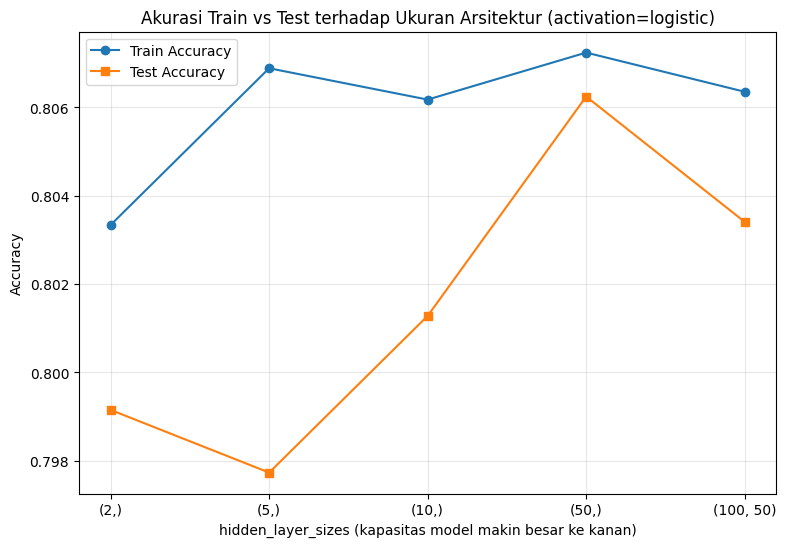


dapat dilihat bahwa akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun


In [21]:
# Plot grafik akurasi training vs testing terhadap ukuran arsitektur dalam satu chart.

plt.figure(figsize=(9, 6))
plt.plot(results_arch_df.index, results_arch_df['Train Accuracy'], marker='o', label='Train Accuracy')
plt.plot(results_arch_df.index, results_arch_df['Test Accuracy'], marker='s', label='Test Accuracy')
plt.xlabel('hidden_layer_sizes (kapasitas model makin besar ke kanan)')
plt.ylabel('Accuracy')
plt.title(f'Akurasi Train vs Test terhadap Ukuran Arsitektur (activation={best_act})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print("\ndapat dilihat bahwa akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun")

# 4. Evaluasi Model

In [22]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model dengan performa terbaik dari tiap eksperimen (3.2 dan 3.3).
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
from sklearn.metrics import precision_score, recall_score, f1_score

best_models = {
    f"3.2 Aktivasi terbaik ({best_act}, (10,))": models_act[best_act],
    f"3.3 Arsitektur terbaik {best_arch} ({best_act})": models_arch[best_arch]
}

metrics_rows = []
for nama, model in best_models.items():
    y_pred = model.predict(X_test_scaled)
    metrics_rows.append({
        'Model': nama,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),   # kelas positif = Churn (1)
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })
metrics_df = pd.DataFrame(metrics_rows).set_index('Model')
print(metrics_df.round(4))

                                         Accuracy  Precision  Recall  F1-Score
Model                                                                         
3.2 Aktivasi terbaik (logistic, (10,))     0.8013     0.6516  0.5401    0.5906
3.3 Arsitektur terbaik (50,) (logistic)    0.8062     0.6624  0.5508    0.6015


Model terbaik: 3.3 Arsitektur terbaik (50,) (logistic)


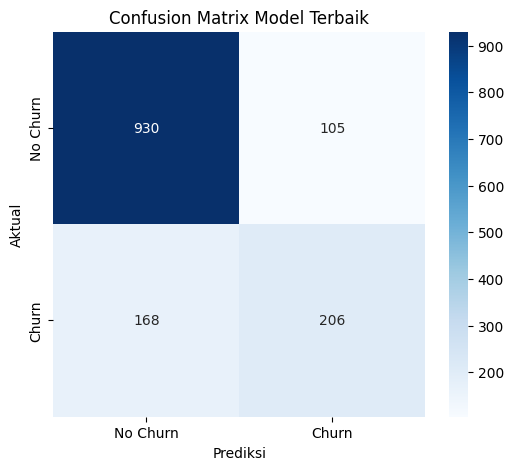

              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.55      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [23]:
# Tampilkan Confusion Matrix untuk model dengan performa terbaik dalam bentuk heatmap.
# Pilih model terbaik keseluruhan (akurasi test tertinggi, jika sama dilihat F1-Score)
best_model_name = metrics_df.sort_values(['Accuracy', 'F1-Score'], ascending=False).index[0]
best_model = best_models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)
print("Model terbaik:", best_model_name)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Model Terbaik')
plt.show()

print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

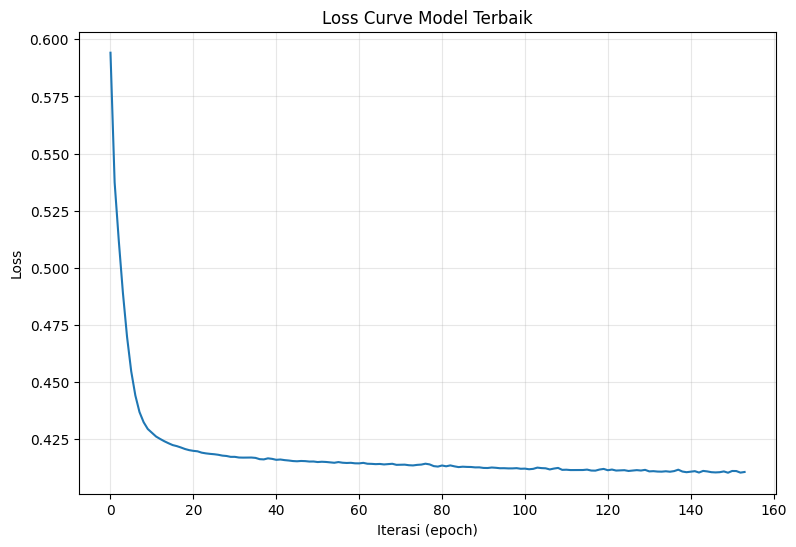

Iterasi berjalan: 154 | max_iter: 500
Loss akhir: 0.4106
Training berhenti sebelum max_iter -> loss sudah konvergen (perbaikan < tol selama 10 iterasi berturut-turut).


In [24]:
# Plot loss curve dari model dengan performa terbaik (atribut model.loss_curve_).
# Amati apakah loss sudah konvergen atau masih menurun saat max_iter tercapai.
plt.figure(figsize=(9, 6))
plt.plot(best_model.loss_curve_)
plt.xlabel('Iterasi (epoch)')
plt.ylabel('Loss')
plt.title('Loss Curve Model Terbaik')
plt.grid(alpha=0.3)
plt.show()

n_iter = best_model.n_iter_
print("Iterasi berjalan:", n_iter, "| max_iter:", best_model.max_iter)
print("Loss akhir:", round(best_model.loss_curve_[-1], 5))
if n_iter < best_model.max_iter:
    print("Training berhenti sebelum max_iter -> loss sudah konvergen (perbaikan < tol selama 10 iterasi berturut-turut).")
else:
    print("Training mencapai max_iter -> loss BELUM tentu konvergen, pertimbangkan max_iter lebih besar.")

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa ANN dengan fungsi aktivasi ReLU, Tanh, dan Logistic. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (ukuran arsitektur). Pada ukuran arsitektur berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Berdasarkan loss curve yang dihasilkan, apakah model sudah cukup konvergen? Apa yang akan kalian lakukan jika loss curve masih menurun tajam saat max_iter tercapai?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

**1. Perbandingan fungsi aktivasi (ReLU, Tanh, Logistic).**

Jika selisihnya hanya beberapa persen atau kurang, perbedaannya tidak signifikan. Dugaan penyebabnya: arsitektur kecil `(10,)` dengan satu hidden layer dan data tabular yang sudah di-scaling, sehingga ketiga fungsi aktivasi sama-sama cukup untuk mempelajari pola yang ada. Secara teori, ReLU tidak mengalami saturasi untuk nilai positif sehingga gradien lebih stabil dan konvergensi cenderung lebih cepat. Tanh dan Logistic mengalami saturasi pada input besar (gradien mengecil), dan Logistic tidak berpusat di nol sehingga secara teori konvergensinya cenderung lebih lambat. Karena pada praktiknya perbedaan lebih mudah terlihat di jumlah iterasi daripada di akurasi.

**2. Pengaruh ukuran arsitektur terhadap overfitting.**
Ciri overfitting : kurva akurasi train terus naik seiring bertambahnya neuron/layer, sedangkan kurva test mendatar atau turun sehingga jarak (*gap*) di antara keduanya melebar. Titik awal overfitting ditunjukkan oleh ringkasan otomatis di atas dan kolom *Gap (Train - Test)*. Arsitektur yang terlalu kecil (misalnya `(2,)`) justru berpotensi *underfitting*: akurasi train dan test sama-sama rendah dan gap-nya kecil.

**3. Konvergensi loss curve.**
Jika training berhenti sebelum `max_iter`, berarti perbaikan loss sudah lebih kecil dari `tol` dan model dianggap konvergen. Jika loss masih menurun tajam saat `max_iter` tercapai, langkah yang dapat dilakukan: menaikkan `max_iter`, menyesuaikan `learning_rate_init`, mencoba solver lain, atau memakai `early_stopping=True` agar training berhenti otomatis tanpa menambah risiko overfitting.

**Catatan tambahan:** dataset ini imbalanced (sekitar 73% No dan 27% Yes), sehingga akurasi saja bisa menyesatkan. Perhatikan juga Recall dan F1-Score kelas Churn dan confusion matrix, karena pelanggan churn yang tidak terdeteksi adalah kerugian utama bagi bisnis.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba solver lain seperti 'sgd', menambahkan regularisasi alpha, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

**Kesimpulan**
1. Dataset Telco Customer Churn bersifat imbalanced (sekitar 73% tidak churn). Kolom `TotalCharges` berisi nilai spasi (11 pelanggan dengan `tenure` = 0) yang tidak terdeteksi `isnull()`, sehingga dikonversi ke numerik dan diisi 0 (berdasarkan logika bisnis, tanpa data leakage).
2. Pada arsitektur dasar `(10,)`, perbandingan ReLU, Tanh, dan Logistic dapat dilihat pada tabel 3.2 (selisih akurasi test terbaik vs terburuk dicetak pada ringkasan Bab 5). Fungsi aktivasi dengan akurasi test tertinggi dipakai pada eksperimen 3.3.
3. Pada eksperimen 3.3, gejala overfitting dikenali ketika akurasi train terus naik sementara akurasi test mendatar atau turun (lihat grafik 3.3, kolom *Gap*, dan ringkasan Bab 5). Arsitektur yang lebih besar belum tentu lebih baik pada data test.
4. Model terbaik dipilih berdasarkan akurasi test (dan F1-Score sebagai pembeda); evaluasinya dilengkapi Precision, Recall, F1, confusion matrix, dan loss curve.

**Saran**
- Coba `alpha` (L2 regularization) lebih besar, `early_stopping=True`, atau solver `sgd` dan bandingkan dengan `adam`.
- Lakukan hyperparameter tuning dengan `GridSearchCV`/`RandomizedSearchCV` (cross-validation) pada `hidden_layer_sizes`, `alpha`, dan `learning_rate_init`.
- Tangani imbalance (oversampling seperti SMOTE pada train set saja, atau penyesuaian threshold prediksi) dan jadikan Recall/F1 kelas Churn sebagai metrik utama.
- Bandingkan dengan model lain (Logistic Regression, Random Forest, Gradient Boosting) sebagai pembanding.